# Quantum Annealing - Noiseless Simulation

In this notebook we simulate the D-Wave quantum annealing process without noise and analyze the spectral gap.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

from Problem.IsingProblem import IsingProblem
from Algorithm.Classical_Algorithm.Exhaustive_search import exhaustive_search
from quantum_solver.dwave_simulator import (DwaveSimulator, plot_eigenvalues,
    plot_spectral_gap, create_ising_instance_random)

## Small problem example (<10 variables)

In [2]:
# Create a small Ising instance with 5 variables
ising5 = create_ising_instance_random(5, weight_range=1.0, seed=42)
print(f"Number of variables : {ising5.n}")
print(f"Matrix size : {2**ising5.n} x {2**ising5.n}")

# Verify optimal with exhaustive search
best_sol, best_cost = exhaustive_search(ising5, maximize=False)
print(f"Optimal cost (exhaustive) : {best_cost:.6f}")
print(f"Optimal solution : {best_sol}")

Number of variables : 5
Matrix size : 32 x 32
Optimal cost (exhaustive) : -5.218237
Optimal solution : {'s_0': 1, 's_1': -1, 's_2': 1, 's_3': -1, 's_4': 1}


In [3]:
# Run the simulation
sim = DwaveSimulator(n_steps=101)
all_eigenvalues, all_eigenvectors = sim.simulate_evolution(ising5, nb_eigenvalues=5)

print(f"Eigenvalues at step 0 : {all_eigenvalues[0]}")
print(f"Eigenvalues at last step : {all_eigenvalues[-1]}")
print(f"Lowest eigenvalue at end : {all_eigenvalues[-1][0]:.6f}")
print(f"Expected optimal : {best_cost:.6f}")

Eigenvalues at step 0 : [-5. -3. -3. -3. -3.]
Eigenvalues at last step : [-5.21823713 -4.40232564 -3.26450944 -2.64744632 -2.4891889 ]
Lowest eigenvalue at end : -5.218237
Expected optimal : -5.218237


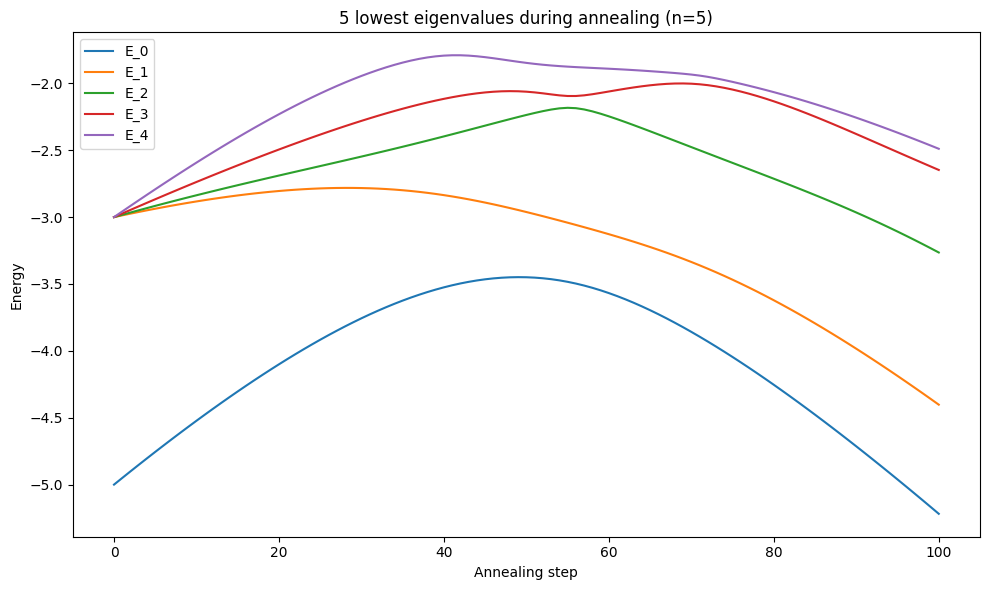

In [4]:
# Plot the 5 lowest eigenvalues
plt.figure(figsize=(10, 6))
plot_eigenvalues(all_eigenvalues, title="5 lowest eigenvalues during annealing (n=5)")
plt.tight_layout()
plt.show()

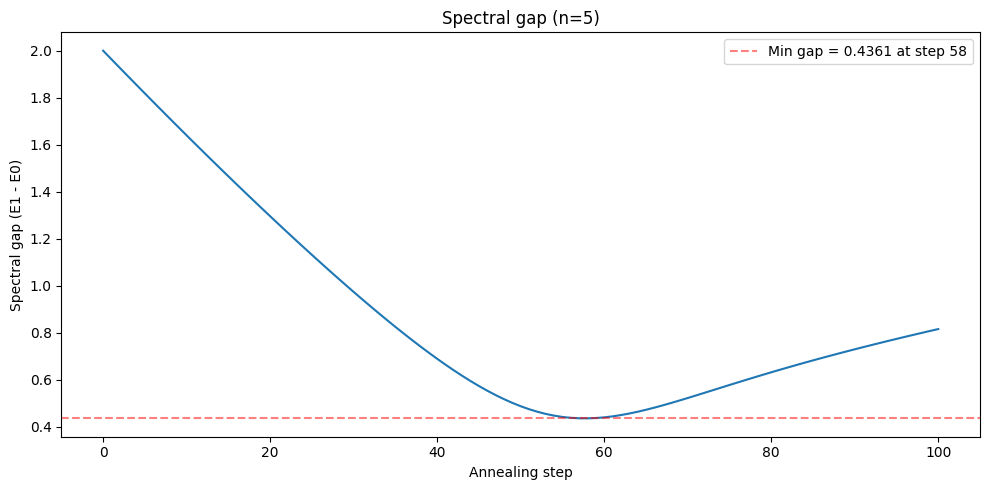

In [5]:
# Plot the spectral gap
plt.figure(figsize=(10, 5))
plot_spectral_gap(all_eigenvalues, title="Spectral gap (n=5)")
plt.tight_layout()
plt.show()

## Different problem sizes (3-12 variables)

We generate Ising instances of different sizes with the same weight distribution and compare their spectral gaps.

In [6]:
sizes_to_test = [3, 4, 5, 6, 7, 8, 9, 10]
min_gaps = {}
sim = DwaveSimulator(n_steps=101)

for n in sizes_to_test:
    ising_n = create_ising_instance_random(n, weight_range=1.0, seed=42)
    eigs, _ = sim.simulate_evolution(ising_n, nb_eigenvalues=2)
    gaps = [eigs[s][1] - eigs[s][0] for s in range(len(eigs))]
    min_gap = min(gaps)
    min_gaps[n] = min_gap
    print(f"n={n} : min spectral gap = {min_gap:.6f}, matrix size = {2**n}x{2**n}")

n=3 : min spectral gap = 0.463649, matrix size = 8x8
n=4 : min spectral gap = 0.007003, matrix size = 16x16
n=5 : min spectral gap = 0.436110, matrix size = 32x32
n=6 : min spectral gap = 0.190763, matrix size = 64x64


n=7 : min spectral gap = 0.007688, matrix size = 128x128


n=8 : min spectral gap = 0.006719, matrix size = 256x256


n=9 : min spectral gap = 0.433330, matrix size = 512x512


n=10 : min spectral gap = 0.205007, matrix size = 1024x1024


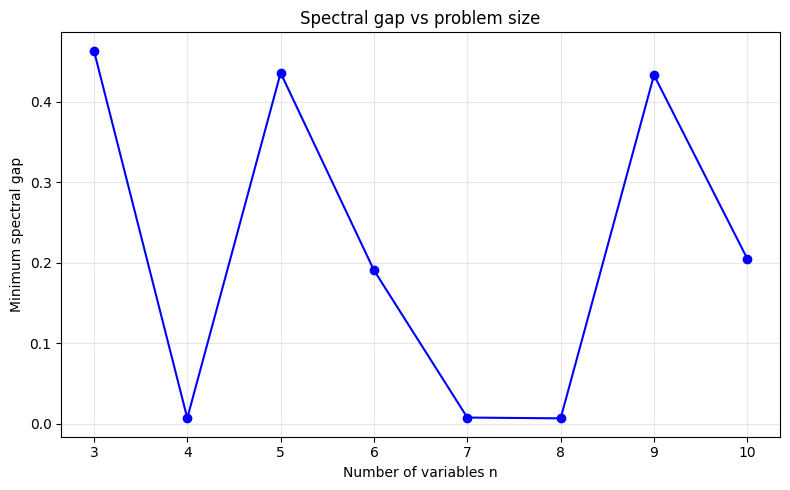

In [7]:
# Plot min spectral gap vs problem size
plt.figure(figsize=(8, 5))
plt.plot(list(min_gaps.keys()), list(min_gaps.values()), 'bo-')
plt.xlabel('Number of variables n')
plt.ylabel('Minimum spectral gap')
plt.title('Spectral gap vs problem size')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

We can observe that the spectral gap generally tends to **decrease** as the problem size increases. This is expected because larger problems have more complex energy landscapes, and the gap between the ground state and the first excited state tends to close exponentially with the system size. This is known as the "exponential closing" of the spectral gap, and it is the main reason why quantum annealing becomes harder for larger instances.

In general, the spectral gap should scale as O(exp(-c*n)) for hard instances, where c is a constant that depends on the problem structure. This means the time required for the quantum evolution grows exponentially.

## Rescaling the weights of H_final

We take a single instance and rescale its weights by different factors to see how the spectral gap changes.

In [8]:
# Take a 6-variable instance
ising_base = create_ising_instance_random(6, weight_range=1.0, seed=42)

scale_factors = [0.25, 0.5, 1.0, 2.0, 4.0]
gaps_by_scale = {}

for scale in scale_factors:
    # Rescale: create new Ising with scaled weights
    w_scaled = {k: v * scale for k, v in ising_base.w.items()}
    J_scaled = {k: v * scale for k, v in ising_base.J.items()}
    # Rebuild Ising from scaled weights
    w_list = [w_scaled[i] for i in range(ising_base.n)]
    J_matrix = np.zeros((ising_base.n, ising_base.n))
    for (i, j), val in J_scaled.items():
        J_matrix[i][j] = val
    ising_scaled = IsingProblem((w_list, J_matrix))
    eigs, _ = sim.simulate_evolution(ising_scaled, nb_eigenvalues=2)
    gaps = [eigs[s][1] - eigs[s][0] for s in range(len(eigs))]
    gaps_by_scale[scale] = gaps
    print(f"scale={scale} : min gap = {min(gaps):.6f}")

scale=0.25 : min gap = 0.047904


scale=0.5 : min gap = 0.095808
scale=1.0 : min gap = 0.190763
scale=2.0 : min gap = 0.349687
scale=4.0 : min gap = 0.419567


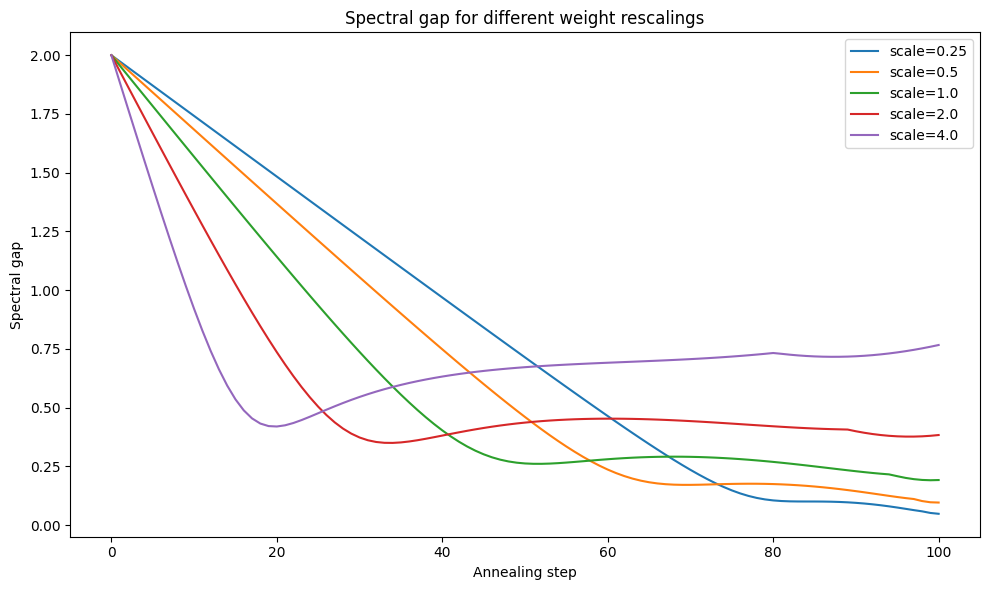

In [9]:
plt.figure(figsize=(10, 6))
for scale in scale_factors:
    plt.plot(range(101), gaps_by_scale[scale], label=f"scale={scale}")
plt.xlabel('Annealing step')
plt.ylabel('Spectral gap')
plt.title('Spectral gap for different weight rescalings')
plt.legend()
plt.tight_layout()
plt.show()

## Analysis of rescaling and programming range

When we rescale the weights of H_final by a factor k, the spectral gap also changes. Specifically, when we increase the weights (scale > 1), the spectral gap tends to get smaller. This is because the problem Hamiltonian H_final becomes "stronger" relative to the initial Hamiltonian H_init, and the crossing between energy levels happens more abruptly.

In quantum annealers like D-Wave, the programming range is finite (for example h_i in [-1, +1] and J_ij in [-2, +2]). If a problem has weights that exceed this range, we need to **rescale** them to fit. This rescaling effectively divides all weights by a constant factor, which means we are making the problem Hamiltonian weaker relative to the transverse field.

Looking at our results, when the scale factor is smaller (weights are smaller), the spectral gap is actually **larger**. This is good for the annealing because a larger gap means the system can evolve more slowly and still stay in the ground state (adiabatic theorem).

However, this rescaling also makes the energy differences between solutions smaller, which means the problem becomes more sensitive to noise and thermal fluctuations. So there is a tradeoff : rescaling makes the gap larger (easier for the adiabatic evolution) but also makes the energy landscape flatter (harder to distinguish good solutions from bad ones in the presence of noise).

In practice, if we need to rescale the problem to fit in the programming range, it generally **worsens** the resolution because the signal-to-noise ratio decreases.